In [5]:
pip install -q scikit-learn pandas numpy matplotlib scipy gymnasium tqdm

Note: you may need to restart the kernel to use updated packages.


In [6]:
import gymnasium as gym
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

Load environment

In [14]:
env = gym.make('FrozenLake-v1')

Setup

In [9]:
lr           = 0.8 # learning rate อัตราการเรียนรู้
gamma        = 0.95 # discount rate 
num_episodes = 10000 # จำนวนรอบของเกมส์ที่เราจะเล่น
max_steps    = 99 # จำนวนครั้ง action ที่เลือกได้มากสุด ต่อ 1 เกมส์

# การปรับ epsilon มีอยู่หลายวิธี นี้่เป็นหนึ่งในวิธีการปรับ
epsilon      = 1.0 # ค่าการเรียนรู้ epsilon greedy
max_epsilon  = 1.0 # ใช้สำหรับอัพเดท epsilon 
min_epsilon  = 0.001 # ใช้สำหรับอัพเดท epsilon 
decay_rate   = 0.005  # ใช้สำหรับอัพเดท epsilon 

action_size  = env.action_space.n # จำนวน action ที่สามารถเลือกได้
state_size   = env.observation_space.n # จำนวน state ทั้งหมดในเกมส์

qtable       = np.zeros((state_size, action_size)) # ตาราง q-table
print(qtable)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Update Q-Table

100%|██████████| 10000/10000 [00:07<00:00, 1264.63it/s]


Score over time: 0.6257
[[1.50333911e-01 4.64659287e-02 2.72556754e-02 2.62169250e-02]
 [4.94884996e-03 2.35325622e-03 2.61991974e-03 4.99545959e-02]
 [1.90345453e-02 2.41931122e-03 4.22509356e-03 5.58832888e-03]
 [3.08928129e-03 1.46171020e-03 2.14449392e-04 5.94443617e-03]
 [2.06158414e-01 4.56592143e-04 1.00367348e-02 1.43602057e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.26900432e-07 4.41706711e-07 1.61681127e-03 2.04320075e-07]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.42710710e-03 7.28306172e-04 1.54510273e-03 3.47870628e-01]
 [8.92137968e-03 4.87900363e-01 6.04032034e-03 3.19878906e-02]
 [6.11113802e-01 4.69810287e-05 2.42444691e-03 1.66010283e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.59721331e-02 2.51462270e-02 6.14272272e-01 5.41504810e-02]
 [7.82021136e-02 9.34555274e-01 8.33964043e-02 1.01547258e-01]
 [0.00000000e+00 0.00000000e+00

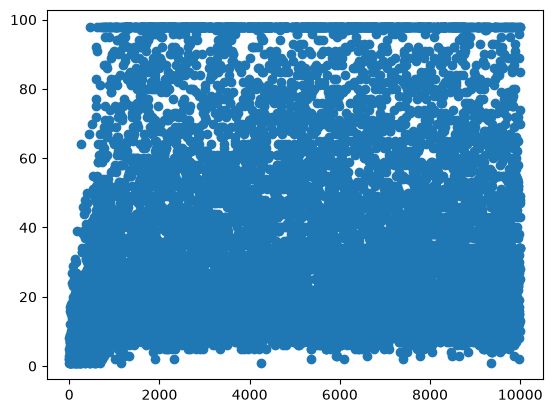

In [16]:
rewards = []
avg_rewards = []
total_step = []

for episode in tqdm(range(num_episodes)):
    # เริ่มต้น
    state, _ = env.reset() # state เริ่มต้น
    step = 0 # จำนวน action
    done = False # เอาไว้เช็คว่า เกมส์จบหรือยัง
    total_rewards = 0
    
    for step in range(max_steps):
        
        # ถ้าเรา random ช่วง 0-1 แล้วมีค่ามากกว่า epsilon เราจะ exploit (greedy)
        if random.uniform(0, 1) > epsilon: 
            action = np.argmax(qtable[state,:])
        else: # ถ้าได้น้อยกว่า เราจะ random เลือก action
            action = env.action_space.sample()

        state_, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q(s,a) = Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        qtable[state, action] = qtable[state, action] + lr * (reward + gamma * np.max(qtable[state_, :]) - qtable[state, action])
        
        total_rewards += reward
        
        # เปลี่ยน state เป็น state หลังจาก action ไปแล้ว
        state = state_
        
        # ถ้าเกมส์จบก็หยุด (ชนะ ไม่ก็ตาย)
        if done == True:
            break
        
    # ปรับ epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    
    total_step.append(step)
    rewards.append(total_rewards)
    avg_rewards.append(total_rewards/(episode+1))

print ("Score over time: " +  str(sum(rewards)/num_episodes))
print(qtable)
_ = plt.scatter(range(num_episodes), total_step)

Play

In [19]:
env.reset()

for episode in range(5):
    state, _ = env.reset()
    step = 0
    done = False
    print("****************************************************")
    print("EPISODE ", episode)

    for step in range(max_steps):
        
        # เลือก action แบบ exploit อย่างเดียว ไม่มีการ explore
        action = np.argmax(qtable[state,:])
        
        state_, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        if done:
            # แสดงผลเมื่อเกมส์จบ
            env.render()
            
            print("Number of steps", step)
            break
        state = state_
env.close()

****************************************************
EPISODE  0
Number of steps 18
****************************************************
EPISODE  1
Number of steps 31
****************************************************
EPISODE  2
Number of steps 7
****************************************************
EPISODE  3
Number of steps 20
****************************************************
EPISODE  4


c:\Users\phongsakon.bua\Desktop\Project_AIPrediction\.venv\Lib\site-packages\gymnasium\envs\toy_text\frozen_lake.py:352: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("FrozenLake-v1", render_mode="rgb_array")
  gym.logger.warn(
